## Dependencies

In [14]:
from IPython.display import Image, display
from typing import Annotated, List, Literal, TypedDict
from dotenv import load_dotenv
import uuid
from IPython.display import Markdown, display

load_dotenv()

True

## Define errors

In [8]:
class LLMError(Exception):
    """Base class for LLM-related failures."""
    def __init__(self, message: str, *, original: Exception | None = None, retriable: bool = False):
        super().__init__(message)
        self.original = original
        self.retriable = retriable

class LLMInvocationError(LLMError):
    """Raised when the LLM call itself fails (network, API, etc.)."""

class LLMResponseFormatError(LLMError):
    """Raised when the LLM returns an unexpected / invalid format."""

## Define state schemas

In [9]:
class ImageDiffClassification(TypedDict):
    diff_percentage: float
    change_type: Literal["minor", "moderate", "major"]
    list_of_changes: List[str]
    summary: str

class ImageDiffState(TypedDict):
    # Raw image data
    before_image_path: str
    after_image_path: str
    report_id : str
    vehicle_side: Literal["left", "right", "front", "rear", "top"]

    # Uploaded image data
    before_image_uri: str | None
    after_image_uri: str | None

    # Classification data
    classification: ImageDiffClassification | None

    # Generated diff analysis report
    analysis_report: str | None
    date: str | None

## Define Nodes, Edges

In [ ]:
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langchain_google_genai import ChatGoogleGenerativeAI
from google import genai
import time

def read_images(state: ImageDiffState) -> ImageDiffState: # type: ignore
    """Extract and parse image data from the state."""
    pass

client = genai.Client()

def upload_images(state: ImageDiffState) -> ImageDiffState:
    """Uploads image files from given paths to Google servers, then saves their URIs to the state."""

    # Upload images to Google's servers
    before_file = client.files.upload(file=state["before_image_path"])

    while before_file.state.name == "PROCESSING":
        time.sleep(2)
        if before_file.name is None:
            raise ValueError("File name is None while processing.")
        
        before_file = client.files.get(name=before_file.name)

    after_file = client.files.upload(file=state["after_image_path"])
    while after_file.state.name == "PROCESSING":
        time.sleep(2)
        if after_file.name is None:
            raise ValueError("File name is None while processing.")
        after_file = client.files.get(name=after_file.name)
    
    return {
        "before_image_uri": before_file.uri, 
        "after_image_uri": after_file.uri
        } # type: ignore

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

from langchain.messages import HumanMessage

def classify_image_diff(state: ImageDiffState) -> ImageDiffState:
    """Classifies the differences between an image pair using an LLM."""

    try:
        # Create a structured LLM that returns ImageDiffClassification dict
        structured_llm = llm.with_structured_output(ImageDiffClassification) # type: ignore

        classification_prompt = f"""
        You are an image analysis expert who specializes in identifying visible changes to the exterior of vehicles. 
        Given two images of a vehicle, analyze the exterior body for differences and classify them.

        Before Vehicle Image Data: {state['before_image_uri']}
        After Vehicle Image Data: {state['after_image_uri']}

        Please provide:
        1. diff_percentage: A float representing the percentage of difference between the vehicle images.
        2. change_type: One of "minor", "moderate", "major".
        3. list_of_changes: A list of strings describing the physical changes visible on the exterior of the vehicle.
        4. summary: A brief summary of the differences.

        MAKE SURE TO IGNORE:
        - Any irrelevant background changes.
        - Lighting or angle variations.
        - Any changes that do not significantly alter the content of the images.
        - Ignore shadows, glare, and reflections.

        Respond in JSON format.
        """

        # Formatting message with appropriate headers, image file references, and prompt
        message = HumanMessage(
            content=[
                {"type": "text", "text": classification_prompt},
                {
                    "type": "file",
                    "file_id": state['before_image_uri'],
                    "mime_type": "image/jpeg"
                }, 
                {
                    "type": "file",
                    "file_id": state['after_image_uri'],
                    "mime_type": "image/jpeg"
                }, 
            ]
        )

        # Get structured response directly as a dict
        classification = structured_llm.invoke([message])

        # Store classification as a single dict in state
        return {"classification": classification}  # type: ignore
    
    except Exception as e:
        # classify whether retriable (network/timeouts) or permanent (bad format)
        retriable = isinstance(e, (TimeoutError, ConnectionError))
        # log the original error (use logging in production)
        print(f"[classify_image_diff] LLM classify failed: {e}")
        raise LLMInvocationError("LLM classify failed", original=e, retriable=retriable) from e

def generate_analysis_report(state: ImageDiffState) -> Command[Literal["human_review", "send_report"]]:
    """Generates a detailed analysis report based on the classification."""
    
    classification = state.get("classification")

    if classification is None:
        raise ValueError("Classification data is missing in state.")
    
    try:
        date = time.strftime("%Y-%m-%d")
        report_prompt = f"""
        Instructions:
        Based on the following classification of image differences, generate a concise analysis report and highlight the key findings with proper formatting.
        Include a title, date ({date}), report ID ({state["report_id"]}), headings, and subheadings. 
        Utilize the vehicle side information ({state['vehicle_side']}) to both provide damage location context in the report and to title the report. 
        Utilize the report ID ({state['report_id']}) and date ({date}) for reference.
        Ensure clarity and professionalism in the language used. 

        Classification:
        Diff Percentage: {classification['diff_percentage']}
        Change Type: {classification['change_type']}
        List of Changes: {classification['list_of_changes']}
        Summary: {classification['summary']}

        Please provide a comprehensive analysis report.
        """
        # Get structured response directly as a 
        analysis_report = llm.invoke(report_prompt)

        needs_review = (
            classification["diff_percentage"] > 50.0 or 
            classification["change_type"] == "major"
        )

        if needs_review:
            goto = "human_review"
            print("Needs approval from human reviewer.")
        else:
            goto = "send_report"
            print("No human review needed.")
        
        return Command(
            update = {"analysis_report": analysis_report.content, "date": date},
            goto = goto
        )

    except Exception as e:
        # classify whether retriable (network/timeouts) or permanent (bad format)
        retriable = isinstance(e, (TimeoutError, ConnectionError))
        # log the original error (use logging in production)
        print(f"[generate_analysis_report] LLM report generation failed: {e}")
        raise LLMInvocationError("LLM report generation failed", original=e, retriable=retriable) from e

def human_review(state: ImageDiffState) -> Command[Literal["send_report", END]]:
    """Pause for human review of the analysis report."""

    classification = state.get("classification")
    if classification is None:
        raise ValueError("Classification data is missing in state.")

    # Interrupt comes first to prevent code re-runs
    human_decision = interrupt({
        "diff_percentage": classification.get("diff_percentage"),
        "change_type": classification.get("change_type"),
        "list_of_changes": classification.get("list_of_changes"),
        "summary": classification.get("summary"),
        "analysis_report": state.get("analysis_report"),
        "action": "Please review and approve / revise the analysis report."
    })

    if human_decision.get("approved"):
        goto = "send_report"
        print("Human reviewer approved the report.")
    else:
        goto = END
        print("Human reviewer rejected the report.")
    
    return Command(
        update = {},
        goto = goto
    )

def send_report(state: ImageDiffState) -> ImageDiffState:
    """Send the analysis report."""
    analysis_report = state.get("analysis_report")
    if analysis_report is None:
        raise ValueError("Analysis report is missing in state.")

    print(f"Sending report: {analysis_report[:30]}...")
    return {} # type: ignore

## Build graph

In [11]:
# Create the graph
builder = StateGraph(ImageDiffState)

# Add nodes
builder.add_node("read_images",read_images)
builder.add_node("upload_images", upload_images)
builder.add_node("classify_image_diff", classify_image_diff)
builder.add_node("generate_analysis_report", generate_analysis_report)
builder.add_node("human_review", human_review)
builder.add_node("send_report", send_report)

# Add edges
builder.add_edge(START, "read_images")
builder.add_edge("read_images", "upload_images")
builder.add_edge("upload_images", "classify_image_diff")
# builder.add_edge(START, "classify_image_diff")
builder.add_edge("classify_image_diff", "generate_analysis_report")
builder.add_edge("send_report", END)

# Compile with checkpointer for peristent memory
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
app = builder.compile(checkpointer=memory)

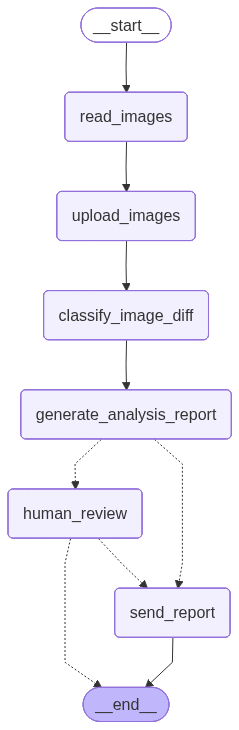

In [12]:
display(Image(app.get_graph().draw_mermaid_png()))

## Testing

In [23]:
# Single run example with left side vehicle images
initial_state : ImageDiffState = {
    "before_image_path": "images/before-images/before-left-side.jpg", 
    "after_image_path": "images/after-images/after-left-side.jpg",
    "report_id": "report_0",
    "vehicle_side": "left"
}  # type: ignore

config = {'configurable': {'thread_id': 1}} # Specify a thread to run chatbot and maintain persistent checkpoint memory
result = app.invoke(initial_state, config=config)

No human review needed.
Sending report: ## Driver's Side Vehicle Damag...


In [24]:
# The graph may pause at human_review

# Provide human input to resume
human_input = Command(
    resume = {"approved": True}
)

# Resume final execution
final_result = app.invoke(human_input, config=config)

In [25]:
# Display final analysis report as a markdown formatted cell
from IPython.display import Markdown, display
display(Markdown(f"{final_result['analysis_report']}\n"))

## Driver's Side Vehicle Damage Analysis Report

**Report ID:** report_0
**Date:** 2025-12-27

### 1. Introduction
This report details the findings from an image difference classification analysis, identifying and categorizing damage sustained by a vehicle, specifically focusing on its driver's side.

### 2. Damage Overview
The analysis indicates a `12.5%` difference in the vehicle's state, categorized as `moderate` damage. This suggests a noticeable but not severe level of change to the vehicle's exterior.

### 3. Detailed Findings
The primary area of impact and visible changes are concentrated on the vehicle's driver's side. Specific observations include:
*   **Driver's Side Front Fender:** Significant denting and scratches are present.
*   **Driver's Side Front Door:** Significant denting and scratches are observed.
*   **Driver's Side Rear Door:** Minor scuff marks are noted.

### 4. Key Findings
The damage is predominantly located on the driver's side of the vehicle, with the most impactful damage (significant dents and scratches) concentrated on the front fender and front door. Minor cosmetic damage extends to the rear door, indicating a distributed impact or scrape along the side. The overall classification of damage is moderate, impacting multiple panels.

### 5. Conclusion
In summary, the vehicle has sustained moderate damage on its driver's side, primarily consisting of significant dents and scratches on the front fender and front door, with minor scuff marks extending to the rear door.


In [17]:
# Multiple runs with different before-after image pairs of a vehicle's sides
vehicle_information = [
    {
        "before_image_path": "images/before-images/before-left-side.jpg", 
        "after_image_path": "images/after-images/after-left-side.jpg",
        "vehicle_side": "left"
    },
    {
        "before_image_path": "images/before-images/before-right-side.jpg", 
        "after_image_path": "images/after-images/after-right-side.jpg",
        "vehicle_side": "right"
    },
    {
        "before_image_path": "images/before-images/before-rear-side.jpg", 
        "after_image_path": "images/after-images/after-rear-side.jpg",
        "vehicle_side": "rear"
    },
]

for i, pair in enumerate(vehicle_information):
    initial_state = {
        "before_image_path": pair["before_image_path"],
        "after_image_path": pair["after_image_path"],
        "vehicle_side": pair["vehicle_side"],
        "report_id": f"report_{i}"
    }

    thread_id = uuid.uuid4()
    config = {'configurable': {'thread_id': thread_id}} # Specify a thread to run chatbot and maintain persistent checkpoint memory
    result = app.invoke(initial_state, config=config)

    if "__interrupt__" in result.keys():
        # Provide human input to resume
        human_input = Command(
            resume = {"approved": True}
        )

        # Resume final execution
        result = app.invoke(human_input, config=config)
        
    display(Markdown(f"{result['analysis_report']}\n"))

No human review needed.
Sending report: **Driver's Side (Left) Damage ...


**Driver's Side (Left) Damage Analysis Report**

**Report ID**: report_0
**Date**: 2025-12-27

---

**1. Overview**
The image difference analysis indicates a **20.0% change** from the reference state, classifying the overall impact as **moderate**.

**2. Detailed Damage Assessment (Driver's Side - Left)**
A specific assessment of the vehicle's driver's side (left) reveals the following damages:
*   **Front Driver's Side Door**: Significant dent accompanied by notable scratches.
*   **Front Driver's Side Fender**: Presence of a dent and associated scuffing.
*   **Rear Driver's Side Door**: Visible scratches.
*   **Side Trim**: Scuff marks observed on the black plastic trim located below the driver's side doors.

**3. Key Findings**
The vehicle has sustained moderate impact damage primarily localized to its driver's side (left). The key findings highlight a consistent pattern of damage along the entire length of this side, encompassing both structural deformations (dents) and superficial abrasions (scratches and scuff marks). The most pronounced damage, including significant dents and extensive scratches, is concentrated on the front driver's side door and fender, suggesting a primary point of impact or significant contact in that area, with subsequent damage extending to the rear door and side trim.


No human review needed.
Sending report: **Vehicle Right Side Analysis ...


**Vehicle Right Side Analysis Report: report_1**

**Date:** 2025-12-27
**Report ID:** report_1

---

**Analysis Report: Image Difference Classification**

**Overview:**
This report details the classification of image differences identified for the subject vehicle. While this analysis is categorized under the general context of the vehicle's right side, specific findings concerning other areas are documented below.

**Key Findings:**

*   **Overall Difference:** A 'minor' difference was detected, registering a Diff Percentage of 0.5%.
*   **Change Type:** The identified alteration is classified as 'minor'.
*   **Specific Modification:** The primary change observed is the complete removal of the 'STUDENT DRIVER' sticker.
*   **Location Context:** Despite the general analytical focus potentially relating to the vehicle's right side, the specific modification—the removal of the 'STUDENT DRIVER' sticker—was precisely identified on the **rear left side** of the vehicle.

**Summary:**
The analysis reveals a minor alteration to the vehicle, specifically the removal of the 'STUDENT DRIVER' sticker. This modification, representing a minimal difference in the overall image comparison, was localized to the rear left side of the vehicle.


No human review needed.
Sending report: **Analysis Report: Vehicle Rea...


**Analysis Report: Vehicle Rear Damage Assessment**

**Report ID:** report_2
**Date:** 2025-12-27

---

**1. Introduction**
This report provides a concise analysis of observed image differences related to a vehicle's rear section, classifying the nature and extent of changes detected. The assessment is based on a detailed comparison resulting in a quantified difference percentage and specific itemized changes.

**2. Key Findings**

*   **Overall Damage Classification:** The vehicle has sustained **moderate** damage.
*   **Damage Location:** All identified damage is localized to the **tailgate** of the vehicle.
*   **Specific Changes Identified:**
    *   A prominent **dent** has been observed on the tailgate. This dent is specifically located above and to the left of the Hyundai logo.
    *   **Scuff marks** and potential **paint damage** are visible in the immediate vicinity surrounding the Hyundai logo on the tailgate.
*   **Quantitative Difference:** The analysis indicates a **2.0% difference** between the compared images, reflecting the identified alterations.

**3. Analysis and Conclusion**
The vehicle's rear, specifically its tailgate, shows clear evidence of recent impact or contact. The combination of a noticeable dent and surrounding scuffing/paint damage around the Hyundai emblem points to localized trauma. The moderate classification and 2.0% difference percentage quantitatively support the visual assessment of these distinct damages. These findings suggest that the vehicle will require repair, focusing on the tailgate area, to address both cosmetic and structural integrity concerns stemming from the identified dent and surface abrasions.
